# **Indian Job Market Analysis Using EDA**

# Business Problem

####  India's job market is one of the fastest-growing and most competitive in the world. Every year, millions of graduates and experienced professionals search for opportunities across domains like technology, finance,healthcare, and marketing. However, job seekers and career counsellors rarely have access to structured, real-time data about what the market actually looks like — which domains are hiring, which cities have the most openings, what skills are in demand, and what salaries are being offered.
  
 #### This project addresses that gap by scraping live job data from Naukri.com — India's largest job portal — and building a structured analysis of the Indian job market across 9 major domains and 29 job roles.


### Key Questions This Project Answers:
+ Q1 Which domain has the highest number of job postings in India right now?
+ Q2 Which cities are the biggest job hubs across all domains?
+ Q3 What skills are companies demanding the most?
+ Q4 What is the experience range typically required per role and domain?
+ Q5 How transparent are companies about salary — and what does disclosed salary look like?
+ Q6 Which companies are hiring the most across the job market?
+ Q7 What is the relationship between experience and salary?
+ Q8 Does work mode (Onsite/Hybrid/Remote) impact salary levels?

### Step 1 Library Imports & Setup
+ Imported all required libraries including Selenium for browser automation, BeautifulSoup for HTML parsing,
+ Pandas for data storage, Matplotlib and Seaborn for visualization, and WordCloud for text-based visuals.



### Step 2 Define Job Roles & Domains
+ Created a structured list of 29 job role slugs across 9 domains. Each entry is a tuple of (url-slug, domain-name)
+  for example ("data-scientist", "Data & AI"). This list drives the entire scraping loop.


In [18]:
# import library
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import time
import re

C:\Users\ratha\anaconda3\envs\SSRathan14\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


### Step 3 Web Scraping with Selenium
+ Used Selenium with ChromeDriverManager to open a real browser and navigate to each Naukri job listing page.
+ For every role, scraped 3 pages (Page 0, 1, 2). For each job card found via class "srp-jobtuple-wrapper",extracted 6 fields using try/except to handle missing elements gracefully.


In [2]:
# install chromedriver for test
driver=webdriver.Chrome(service=Service(ChromeDriverManager().install()))

### Step 4 Data Stored in Dictionary
+ All scraped data was stored in a Python dictionary with keys: job_no, domain, roles, companies, locations, experience, salaries, skills. This dictionary was then converted directly into a Pandas DataFrame.


In [3]:
# create dictionary for dataframe
jobs={"job_no":[],
    "domain":[],
    "roles":[],
     "companies":[],
     "locations":[],
     "experience":[],
      "salaries":[],
     "skills":[]}

In [4]:
type(jobs)

dict

In [5]:
# define all job roles to scrape from multiple domains
job_roles = [
    # Data & AI Domain
    ("data-scientist",            "Data & AI"),
    ("machine-learning-engineer", "Data & AI"),
    ("data-analyst",              "Data & AI"),
    ("data-engineer",             "Data & AI"),
    ("ai-engineer",               "Data & AI"),

    # Software Development Domain
    ("software-developer",        "Software Development"),
    ("full-stack-developer",      "Software Development"),
    ("backend-developer",         "Software Development"),
    ("frontend-developer",        "Software Development"),
    ("python-developer",          "Software Development"),

    # Cloud & DevOps Domain
    ("devops-engineer",           "Cloud & DevOps"),
    ("cloud-engineer",            "Cloud & DevOps"),
    ("aws-architect",             "Cloud & DevOps"),
    ("site-reliability-engineer", "Cloud & DevOps"),

    # Cybersecurity Domain
    ("cybersecurity-analyst",     "Cybersecurity"),
    ("information-security",      "Cybersecurity"),
    ("ethical-hacker",            "Cybersecurity"),

    # Business & Management Domain
    ("business-analyst",          "Business & Management"),
    ("product-manager",           "Business & Management"),
    ("project-manager",           "Business & Management"),

    # Finance Domain
    ("financial-analyst",         "Finance"),
    ("investment-banker",         "Finance"),
    ("risk-analyst",              "Finance"),

    # Marketing Domain
    ("digital-marketing",         "Marketing"),
    ("seo-specialist",            "Marketing"),
    ("content-marketing",         "Marketing"),

    # Human Resources Domain
    ("hr-manager",                "Human Resources"),
    ("talent-acquisition",        "Human Resources"),

    # Healthcare Domain
    ("healthcare-analyst",        "Healthcare"),
    ("clinical-data-manager",     "Healthcare")
]

In [6]:
# link of website you want to scrap - scraping top 5 pages per role across all domains
job_counter = 1

for role_slug, domain_name in job_roles:
    print(f"\n>>> Scraping Domain: {domain_name} | Role: {role_slug}")
    
    for i in range(3):
        driver.get("https://www.naukri.com/{}-jobs-{}".format(role_slug, i))
        time.sleep(1.5)
        lst = driver.find_elements(By.CLASS_NAME, "srp-jobtuple-wrapper")
        print(f"  Page {i} — {len(lst)} jobs found")

        for item in lst:   #  renamed 'job' to 'item' to avoid conflict
            driver.implicitly_wait(10)

            # Initialize variables
            role = company = location = exp = salary = skill = "NA"

            # Role
            try:
                role = item.find_element(By.CLASS_NAME, "title").text.strip()
            except NoSuchElementException:
                pass

            # Company
            try:
                company = item.find_element(By.CLASS_NAME, "comp-name").text.strip()
            except NoSuchElementException:
                pass

            # Location
            try:
                location = item.find_element(By.CLASS_NAME, "loc-wrap").text.strip()
            except NoSuchElementException:
                pass

            # Experience
            try:
                exp = item.find_element(By.CLASS_NAME, "exp-wrap").text.strip()
            except NoSuchElementException:
                pass

            # Salary
            try:
                salary = item.find_element(By.CLASS_NAME, "sal-wrap").text.strip()
            except NoSuchElementException:
                salary = "Not Disclosed"

            # Skills
            try:
                skill_li = item.find_elements(By.CSS_SELECTOR, ".tags-gt li")
                skill = ",".join([li.text.strip() for li in skill_li])
            except NoSuchElementException:
                skill = "NA"

            # Append Data
            jobs["job_no"].append(job_counter)
            jobs["domain"].append(domain_name)
            jobs["roles"].append(role)
            jobs["companies"].append(company)
            jobs["locations"].append(location)
            jobs["experience"].append(exp)
            jobs["salaries"].append(salary)
            jobs["skills"].append(skill)

            print(job_counter, role)
            job_counter += 1

print(f"\n Total jobs scraped: {job_counter - 1}")


>>> Scraping Domain: Data & AI | Role: data-scientist
  Page 0 — 0 jobs found
  Page 1 — 20 jobs found
1 Data Scientist
2 Data Scientist
3 Data Scientist - Gen AI + NLP & ML
4 Data Scientist
5 Data Scientist -Telecom (RAN+ AI )
6 Data Scientist
7 GenAI Data Scientist - PAN INDIA
8 DE-Data Scientist-VG-W4-CDAO0217
9 Data Scientist
10 Data Scientist AIML
11 Data Scientist 1
12 Data Scientist III
13 Data Scientist 4
14 Data Scientist (Immediate Joiners Only)
15 Data Scientist-Artificial Intelligence
16 Data Scientist
17 Data Scientist
18 Data Scientist-Artificial Intelligence
19 Data Scientist
20 Data Scientist
  Page 2 — 20 jobs found
21 Data Scientist 1
22 Data Scientist
23 Data Scientist / Data Science Engineer
24 Data Scientist (US Value & Access Insights)
25 Data Scientist
26 Data Scientist I
27 Data Scientist (Commercial)
28 Data Scientist (US Value & Access Insights)
29 Data Scientist (Commercial)
30 Data Scientist
31 Data Scientist
32 Data Scientist
33 Data Scientist
34 Data Scie

In [7]:
# convert dictionary to dataframe
df_raw=pd.DataFrame(jobs)
df_raw

,job_no,domain,roles,companies,locations,experience,salaries,skills
0,1,Data & AI,Data Scientist,Apple,Hyderabad,0-8 Yrs,Not Disclosed,"RCA,Statistical analysis,data science,Data mod..."
1,2,Data & AI,Data Scientist,HCLTech,Hyderabad,5-10 Yrs,8-16 Lacs PA,"Artificial Intelligence,Machine Learning,Pytho..."
2,3,Data & AI,Data Scientist - Gen AI + NLP & ML,Tiger Analytics,Hybrid - Chennai,4-9 Yrs,Not Disclosed,"Generative Ai,NLP,Machine Learning,Python,SQL,..."
3,4,Data & AI,Data Scientist,Tata Consultancy Services,"Hyderabad, Chennai",5-10 Yrs,Not Disclosed,"Artificial Intelligence,Machine Learning,Pytho..."
4,5,Data & AI,Data Scientist -Telecom (RAN+ AI ),Airtel,Gurugram,6-11 Yrs,Not Disclosed,"Agentice AI,Radio,Data Science,SON,Python,Crew..."
...,...,...,...,...,...,...,...,...
1775,1776,Healthcare,Clinical Data Specialist,IQVIA,"Hyderabad, Bengaluru",1-6 Yrs,Not Disclosed,"Medidata Rave,Clinical Data Management,Rave,Da..."
1776,1777,Healthcare,Clinical Data Svs Associate Manager,Accenture,Bengaluru,10-14 Yrs,Not Disclosed,"clinical data,resource management,data service..."
1777,1778,Healthcare,Sr Clinical Data Manager,Emmes Group,Bengaluru,4-6 Yrs,Not Disclosed,"CRO,Pharma,Analytical,Clinical trials,Clinical..."
1778,1779,Healthcare,"Sr Manager, Clinical Data Reporting and Analytics",Bristol Myers Squibb,Hyderabad,5-10 Yrs,Not Disclosed,"HP data protector,data reporting,Clinical tria..."


In [8]:
df_raw.to_csv("Indian_job_market_data.csv", index = False)

In [9]:
df_raw.to_csv(r"C:\Users\ratha\OneDrive\Desktop\Indian_job_market_data.csv",index=False)

# Data Cleaning & Data Manipulation

In [10]:
# 1. Strip column name whitespace

df_raw.columns = df_raw.columns.str.strip()

In [12]:
# 2. Fix Label column

df_raw['roles'].unique()

<StringArray>
[                                                   'Data Scientist',
                                'Data Scientist - Gen AI + NLP & ML',
                                'Data Scientist -Telecom (RAN+ AI )',
                                  'GenAI Data Scientist - PAN INDIA',
                                  'DE-Data Scientist-VG-W4-CDAO0217',
                                               'Data Scientist AIML',
                                                  'Data Scientist 1',
                                                'Data Scientist III',
                                                  'Data Scientist 4',
                           'Data Scientist (Immediate Joiners Only)',
 ...
                                         'Clinical Data Manager III',
                        'Manager Clinical Data Management Reporting',
                                 'Manager, Clinical Data Innovation',
                                      'Senior Clinical Data Manager',
 

### Step 5 Role Standardization
+ Raw job titles were messy — "Data Scientist AIML", "GenAI Data Scientist - PAN INDIA", "DE-Data Scientist-VG-W4" all mean the same role. Applied a keyword-matching function to create a new column "roles_standardized" mapping all variants to a clean standard name.

In [13]:
# keywords from job_roles list (red coloured keywords) mapped to standard names
role_mapping = {
    # Data & AI Domain
    "data scientist"          : "Data Scientist",
    "machine learning"        : "Machine Learning Engineer",
    "data analyst"            : "Data Analyst",
    "data engineer"           : "Data Engineer",
    "ai engineer"             : "AI Engineer",

    # Software Development Domain
    "software developer"      : "Software Developer",
    "full stack"              : "Full Stack Developer",
    "backend"                 : "Backend Developer",
    "frontend"                : "Frontend Developer",
    "python developer"        : "Python Developer",

    # Cloud & DevOps Domain
    "devops"                  : "DevOps Engineer",
    "cloud engineer"          : "Cloud Engineer",
    "aws"                     : "AWS Architect",
    "site reliability"        : "Site Reliability Engineer",

    # Cybersecurity Domain
    "cybersecurity"           : "Cybersecurity Analyst",
    "information security"    : "Information Security",
    "ethical hacker"          : "Ethical Hacker",

    # Business & Management Domain
    "business analyst"        : "Business Analyst",
    "product manager"         : "Product Manager",
    "project manager"         : "Project Manager",

    # Finance Domain
    "financial analyst"       : "Financial Analyst",
    "investment banker"       : "Investment Banker",
    "risk analyst"            : "Risk Analyst",

    # Marketing Domain
    "digital marketing"       : "Digital Marketing",
    "seo"                     : "SEO Specialist",
    "content marketing"       : "Content Marketing",

    # Human Resources Domain
    "hr manager"              : "HR Manager",
    "human resource"          : "HR Manager",
    "talent acquisition"      : "Talent Acquisition",

    # Healthcare Domain
    "healthcare analyst"      : "Healthcare Analyst",
    "clinical data"           : "Clinical Data Manager",
}

In [14]:
# function to standardize role name based on keyword match
def standardize_role(role):
    role_lower = role.lower()
    for keyword, standard_name in role_mapping.items():
        if keyword in role_lower:
            return standard_name
    return role   # keep original if no match found

In [15]:
# add new column with standardized role name
df_raw['roles_standardized'] = df_raw['roles'].apply(standardize_role)

In [16]:
# verify - show before and after side by side
df_raw[['roles', 'roles_standardized']].head(20)

,roles,roles_standardized
0,Data Scientist,Data Scientist
1,Data Scientist,Data Scientist
2,Data Scientist - Gen AI + NLP & ML,Data Scientist
3,Data Scientist,Data Scientist
4,Data Scientist -Telecom (RAN+ AI ),Data Scientist
5,Data Scientist,Data Scientist
6,GenAI Data Scientist - PAN INDIA,Data Scientist
7,DE-Data Scientist-VG-W4-CDAO0217,Data Scientist
8,Data Scientist,Data Scientist
9,Data Scientist AIML,Data Scientist


In [17]:
# count standardized roles
role_counts = df_raw['roles_standardized'].value_counts()
print(role_counts)

roles_standardized
Business Analyst                                                         77
Software Developer                                                       65
Information Security                                                     64
SEO Specialist                                                           63
Full Stack Developer                                                     62
                                                                         ..
AR Caller | Freshers & Experienced (US Healthcare)                        1
Inside Sales Executive -( Healthcare preferred or edtech )                1
Analyst III Business Process Transactions / RR                            1
Urgent Hiring - Sales Representative | Healthcare & Medical Equipment     1
AR Calling specilaist                                                     1
Name: count, Length: 162, dtype: int64


In [18]:
# Calculate the total number of entries
total_roles = len(df_raw['roles_standardized'])

# Calculate the percentage of each role
role_percentages = (role_counts / total_roles) * 100

print("Standardized Roles and their Percentages:")
print(role_percentages)

Standardized Roles and their Percentages:
roles_standardized
Business Analyst                                                         4.325843
Software Developer                                                       3.651685
Information Security                                                     3.595506
SEO Specialist                                                           3.539326
Full Stack Developer                                                     3.483146
                                                                           ...   
AR Caller | Freshers & Experienced (US Healthcare)                       0.056180
Inside Sales Executive -( Healthcare preferred or edtech )               0.056180
Analyst III Business Process Transactions / RR                           0.056180
Urgent Hiring - Sales Representative | Healthcare & Medical Equipment    0.056180
AR Calling specilaist                                                    0.056180
Name: count, Length: 162, dtype: floa

In [20]:
# save updated dataframe
df_raw.to_csv('Standardized_Roles_Naukri.csv', index=False)
print("Saved Standardized_Roles_Naukri.csv")

Saved Standardized_Roles_Naukri.csv


In [21]:
df_raw

,job_no,domain,roles,companies,locations,experience,salaries,skills,roles_standardized
0,1,Data & AI,Data Scientist,Apple,Hyderabad,0-8 Yrs,Not Disclosed,"RCA,Statistical analysis,data science,Data mod...",Data Scientist
1,2,Data & AI,Data Scientist,HCLTech,Hyderabad,5-10 Yrs,8-16 Lacs PA,"Artificial Intelligence,Machine Learning,Pytho...",Data Scientist
2,3,Data & AI,Data Scientist - Gen AI + NLP & ML,Tiger Analytics,Hybrid - Chennai,4-9 Yrs,Not Disclosed,"Generative Ai,NLP,Machine Learning,Python,SQL,...",Data Scientist
3,4,Data & AI,Data Scientist,Tata Consultancy Services,"Hyderabad, Chennai",5-10 Yrs,Not Disclosed,"Artificial Intelligence,Machine Learning,Pytho...",Data Scientist
4,5,Data & AI,Data Scientist -Telecom (RAN+ AI ),Airtel,Gurugram,6-11 Yrs,Not Disclosed,"Agentice AI,Radio,Data Science,SON,Python,Crew...",Data Scientist
...,...,...,...,...,...,...,...,...,...
1775,1776,Healthcare,Clinical Data Specialist,IQVIA,"Hyderabad, Bengaluru",1-6 Yrs,Not Disclosed,"Medidata Rave,Clinical Data Management,Rave,Da...",Clinical Data Manager
1776,1777,Healthcare,Clinical Data Svs Associate Manager,Accenture,Bengaluru,10-14 Yrs,Not Disclosed,"clinical data,resource management,data service...",Clinical Data Manager
1777,1778,Healthcare,Sr Clinical Data Manager,Emmes Group,Bengaluru,4-6 Yrs,Not Disclosed,"CRO,Pharma,Analytical,Clinical trials,Clinical...",Clinical Data Manager
1778,1779,Healthcare,"Sr Manager, Clinical Data Reporting and Analytics",Bristol Myers Squibb,Hyderabad,5-10 Yrs,Not Disclosed,"HP data protector,data reporting,Clinical tria...",Clinical Data Manager


In [23]:
df_raw.isna().sum()

job_no                0
domain                0
roles                 0
companies             0
locations             0
experience            0
salaries              0
skills                0
roles_standardized    0
dtype: int64

# Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\ratha\OneDrive\Desktop\Indian_job_market_data.csv")
df

,job_no,domain,roles,companies,locations,experience,salaries,skills
0,1,Data & AI,Data Scientist,Apple,Hyderabad,0-8 Yrs,Not Disclosed,"RCA,Statistical analysis,data science,Data mod..."
1,2,Data & AI,Data Scientist,HCLTech,Hyderabad,5-10 Yrs,8-16 Lacs PA,"Artificial Intelligence,Machine Learning,Pytho..."
2,3,Data & AI,Data Scientist - Gen AI + NLP & ML,Tiger Analytics,Hybrid - Chennai,4-9 Yrs,Not Disclosed,"Generative Ai,NLP,Machine Learning,Python,SQL,..."
3,4,Data & AI,Data Scientist,Tata Consultancy Services,"Hyderabad, Chennai",5-10 Yrs,Not Disclosed,"Artificial Intelligence,Machine Learning,Pytho..."
4,5,Data & AI,Data Scientist -Telecom (RAN+ AI ),Airtel,Gurugram,6-11 Yrs,Not Disclosed,"Agentice AI,Radio,Data Science,SON,Python,Crew..."
...,...,...,...,...,...,...,...,...
1775,1776,Healthcare,Clinical Data Specialist,IQVIA,"Hyderabad, Bengaluru",1-6 Yrs,Not Disclosed,"Medidata Rave,Clinical Data Management,Rave,Da..."
1776,1777,Healthcare,Clinical Data Svs Associate Manager,Accenture,Bengaluru,10-14 Yrs,Not Disclosed,"clinical data,resource management,data service..."
1777,1778,Healthcare,Sr Clinical Data Manager,Emmes Group,Bengaluru,4-6 Yrs,Not Disclosed,"CRO,Pharma,Analytical,Clinical trials,Clinical..."
1778,1779,Healthcare,"Sr Manager, Clinical Data Reporting and Analytics",Bristol Myers Squibb,Hyderabad,5-10 Yrs,Not Disclosed,"HP data protector,data reporting,Clinical tria..."


### Step 6 Feature Engineering — New Columns
+ Created 6 new columns from existing data to enable richer analysis: Min_Exp & Max_Exp: extracted numeric values from "0-8 Yrs" format using regex. Min_Salary & Max_Salary: extracted from salary range strings, cast to numeric. work_mode: simulated distribution (Onsite 60%, Hybrid 30%, Remote 10%). job_status: simulated (Active 86%, Filled 14%). employment_type: simulated (Full-time 92%, Contract 2%, Internship 6%).

In [3]:
df["Min_Exp"] =df["experience"].str.extract(r'(\d+)')
df["Max_Exp"] =df["experience"].str.extract(r'-(\d+)')

In [4]:
df["Min_Exp"] = pd.to_numeric(df["Min_Exp"])
df["Max_Exp"] = pd.to_numeric(df["Max_Exp"])

In [5]:
df["Min_Salary"] =df["salaries"].str.extract(r'(\d+)')
df["Max_Salary"] = df["salaries"].str.extract(r'-(\d+)')

In [6]:
df["Min_Salary"] = pd.to_numeric(df["Min_Salary"],errors="coerce")
df["Max_Salary"] = pd.to_numeric(df["Max_Salary"],errors="coerce")

In [7]:
df["work_mode"] = np.random.choice(
    ["Onsite", "Hybrid", "Remote"],
    size=len(df),
    p=[0.6, 0.3, 0.1]
)

In [8]:
df["job_status"] = np.random.choice(
    ["Active", "Filled"],
    size=len(df),
    p=[0.86, 0.14]
)

In [9]:
df["employment_type"] = np.random.choice(
    ["Full-time", "Contract", "Internship"],
    size=len(df),
    p=[0.92, 0.02, 0.06]
)

In [10]:
df

,job_no,domain,roles,companies,locations,experience,salaries,skills,Min_Exp,Max_Exp,Min_Salary,Max_Salary,work_mode,job_status,employment_type
0,1,Data & AI,Data Scientist,Apple,Hyderabad,0-8 Yrs,Not Disclosed,"RCA,Statistical analysis,data science,Data mod...",0.0,8.0,NaN,NaN,Remote,Active,Full-time
1,2,Data & AI,Data Scientist,HCLTech,Hyderabad,5-10 Yrs,8-16 Lacs PA,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,8.0,16.0,Onsite,Active,Full-time
2,3,Data & AI,Data Scientist - Gen AI + NLP & ML,Tiger Analytics,Hybrid - Chennai,4-9 Yrs,Not Disclosed,"Generative Ai,NLP,Machine Learning,Python,SQL,...",4.0,9.0,NaN,NaN,Remote,Active,Full-time
3,4,Data & AI,Data Scientist,Tata Consultancy Services,"Hyderabad, Chennai",5-10 Yrs,Not Disclosed,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,NaN,NaN,Onsite,Active,Full-time
4,5,Data & AI,Data Scientist -Telecom (RAN+ AI ),Airtel,Gurugram,6-11 Yrs,Not Disclosed,"Agentice AI,Radio,Data Science,SON,Python,Crew...",6.0,11.0,NaN,NaN,Onsite,Active,Full-time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1775,1776,Healthcare,Clinical Data Specialist,IQVIA,"Hyderabad, Bengaluru",1-6 Yrs,Not Disclosed,"Medidata Rave,Clinical Data Management,Rave,Da...",1.0,6.0,NaN,NaN,Hybrid,Active,Full-time
1776,1777,Healthcare,Clinical Data Svs Associate Manager,Accenture,Bengaluru,10-14 Yrs,Not Disclosed,"clinical data,resource management,data service...",10.0,14.0,NaN,NaN,Onsite,Active,Full-time
1777,1778,Healthcare,Sr Clinical Data Manager,Emmes Group,Bengaluru,4-6 Yrs,Not Disclosed,"CRO,Pharma,Analytical,Clinical trials,Clinical...",4.0,6.0,NaN,NaN,Onsite,Active,Full-time
1778,1779,Healthcare,"Sr Manager, Clinical Data Reporting and Analytics",Bristol Myers Squibb,Hyderabad,5-10 Yrs,Not Disclosed,"HP data protector,data reporting,Clinical tria...",5.0,10.0,NaN,NaN,Hybrid,Active,Full-time


In [11]:
df.isna().sum()

job_no                0
domain                0
roles                 0
companies             0
locations             0
experience            2
salaries              0
skills               47
Min_Exp              13
Max_Exp              68
Min_Salary         1467
Max_Salary         1472
work_mode             0
job_status            0
employment_type       0
dtype: int64

In [12]:
df.dropna(subset=['skills','experience'], inplace=True)

In [13]:
df.isna().sum()

job_no                0
domain                0
roles                 0
companies             0
locations             0
experience            0
salaries              0
skills                0
Min_Exp               0
Max_Exp              49
Min_Salary         1434
Max_Salary         1436
work_mode             0
job_status            0
employment_type       0
dtype: int64

In [14]:
df.columns.unique()

Index(['job_no', 'domain', 'roles', 'companies', 'locations', 'experience',
       'salaries', 'skills', 'Min_Exp', 'Max_Exp', 'Min_Salary', 'Max_Salary',
       'work_mode', 'job_status', 'employment_type'],
      dtype='str')

In [16]:
df.head()

,job_no,domain,roles,companies,locations,experience,salaries,skills,Min_Exp,Max_Exp,Min_Salary,Max_Salary,work_mode,job_status,employment_type
0,1,Data & AI,Data Scientist,Apple,Hyderabad,0-8 Yrs,Not Disclosed,"RCA,Statistical analysis,data science,Data mod...",0.0,8.0,NaN,NaN,Remote,Active,Full-time
1,2,Data & AI,Data Scientist,HCLTech,Hyderabad,5-10 Yrs,8-16 Lacs PA,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,8.0,16.0,Onsite,Active,Full-time
2,3,Data & AI,Data Scientist - Gen AI + NLP & ML,Tiger Analytics,Hybrid - Chennai,4-9 Yrs,Not Disclosed,"Generative Ai,NLP,Machine Learning,Python,SQL,...",4.0,9.0,NaN,NaN,Remote,Active,Full-time
3,4,Data & AI,Data Scientist,Tata Consultancy Services,"Hyderabad, Chennai",5-10 Yrs,Not Disclosed,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,NaN,NaN,Onsite,Active,Full-time
4,5,Data & AI,Data Scientist -Telecom (RAN+ AI ),Airtel,Gurugram,6-11 Yrs,Not Disclosed,"Agentice AI,Radio,Data Science,SON,Python,Crew...",6.0,11.0,NaN,NaN,Onsite,Active,Full-time


In [27]:
df["Grouped_Max_Salary"] = df.groupby(
    ["roles"]
)["Max_Exp"].transform("max")

df["Grouped_Min_Salary"] = df.groupby(
    [ "roles"]
)["Min_Exp"].transform("min")

In [28]:
df.drop(columns=["Min_Salary","Max_Salary"],inplace=True)
df.rename(columns={"Grouped_Max_Salary":"Max_Salary","Grouped_Min_Salary":"Min_Salary"},inplace=True)

In [29]:
df

,job_no,domain,roles,companies,locations,experience,salaries,skills,Min_Exp,Max_Exp,work_mode,job_status,employment_type,min_salary,max_salary,exp_mid,exp_band,Max_Salary,Min_Salary
0,1,Data & AI,Data Scientist,Apple,Hyderabad,0-8 Yrs,Not Disclosed,"RCA,Statistical analysis,data science,Data mod...",0.0,8.0,Remote,Active,Full-time,5.0,9.0,4.0,2-5 Yrs,14.0,0.0
1,2,Data & AI,Data Scientist,HCLTech,Hyderabad,5-10 Yrs,8-16 Lacs PA,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,Onsite,Active,Full-time,8.0,16.0,7.5,5-8 Yrs,14.0,0.0
2,3,Data & AI,Data Scientist - Gen AI + NLP & ML,Tiger Analytics,Hybrid - Chennai,4-9 Yrs,Not Disclosed,"Generative Ai,NLP,Machine Learning,Python,SQL,...",4.0,9.0,Remote,Active,Full-time,15.0,23.0,6.5,5-8 Yrs,9.0,4.0
3,4,Data & AI,Data Scientist,Tata Consultancy Services,"Hyderabad, Chennai",5-10 Yrs,Not Disclosed,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,Onsite,Active,Full-time,15.0,23.0,7.5,5-8 Yrs,14.0,0.0
4,5,Data & AI,Data Scientist -Telecom (RAN+ AI ),Airtel,Gurugram,6-11 Yrs,Not Disclosed,"Agentice AI,Radio,Data Science,SON,Python,Crew...",6.0,11.0,Onsite,Active,Full-time,14.0,26.5,8.5,8-12 Yrs,11.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1775,1776,Healthcare,Clinical Data Specialist,IQVIA,"Hyderabad, Bengaluru",1-6 Yrs,Not Disclosed,"Medidata Rave,Clinical Data Management,Rave,Da...",1.0,6.0,Hybrid,Active,Full-time,1.5,5.0,3.5,2-5 Yrs,6.0,1.0
1776,1777,Healthcare,Clinical Data Svs Associate Manager,Accenture,Bengaluru,10-14 Yrs,Not Disclosed,"clinical data,resource management,data service...",10.0,14.0,Onsite,Active,Full-time,1.5,5.0,12.0,8-12 Yrs,14.0,10.0
1777,1778,Healthcare,Sr Clinical Data Manager,Emmes Group,Bengaluru,4-6 Yrs,Not Disclosed,"CRO,Pharma,Analytical,Clinical trials,Clinical...",4.0,6.0,Onsite,Active,Full-time,1.5,5.0,5.0,2-5 Yrs,6.0,4.0
1778,1779,Healthcare,"Sr Manager, Clinical Data Reporting and Analytics",Bristol Myers Squibb,Hyderabad,5-10 Yrs,Not Disclosed,"HP data protector,data reporting,Clinical tria...",5.0,10.0,Hybrid,Active,Full-time,1.5,5.0,7.5,5-8 Yrs,10.0,5.0


In [30]:
df.isna().sum()

job_no              0
domain              0
roles               0
companies           0
locations           0
experience          0
salaries            0
skills              0
Min_Exp             0
Max_Exp            49
work_mode           0
job_status          0
employment_type     0
min_salary          0
max_salary          0
exp_mid            22
exp_band           46
Max_Salary         43
Min_Salary          0
dtype: int64

In [34]:
df.dropna(inplace=True)

In [35]:
df.head()

,job_no,domain,roles,companies,locations,experience,salaries,skills,Min_Exp,Max_Exp,work_mode,job_status,employment_type,min_salary,max_salary,exp_mid,exp_band,Max_Salary,Min_Salary
0,1,Data & AI,Data Scientist,Apple,Hyderabad,0-8 Yrs,Not Disclosed,"RCA,Statistical analysis,data science,Data mod...",0.0,8.0,Remote,Active,Full-time,5.0,9.0,4.0,2-5 Yrs,14.0,0.0
1,2,Data & AI,Data Scientist,HCLTech,Hyderabad,5-10 Yrs,8-16 Lacs PA,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,Onsite,Active,Full-time,8.0,16.0,7.5,5-8 Yrs,14.0,0.0
2,3,Data & AI,Data Scientist - Gen AI + NLP & ML,Tiger Analytics,Hybrid - Chennai,4-9 Yrs,Not Disclosed,"Generative Ai,NLP,Machine Learning,Python,SQL,...",4.0,9.0,Remote,Active,Full-time,15.0,23.0,6.5,5-8 Yrs,9.0,4.0
3,4,Data & AI,Data Scientist,Tata Consultancy Services,"Hyderabad, Chennai",5-10 Yrs,Not Disclosed,"Artificial Intelligence,Machine Learning,Pytho...",5.0,10.0,Onsite,Active,Full-time,15.0,23.0,7.5,5-8 Yrs,14.0,0.0
4,5,Data & AI,Data Scientist -Telecom (RAN+ AI ),Airtel,Gurugram,6-11 Yrs,Not Disclosed,"Agentice AI,Radio,Data Science,SON,Python,Crew...",6.0,11.0,Onsite,Active,Full-time,14.0,26.5,8.5,8-12 Yrs,11.0,6.0


In [36]:
df.isna().sum()

job_no             0
domain             0
roles              0
companies          0
locations          0
experience         0
salaries           0
skills             0
Min_Exp            0
Max_Exp            0
work_mode          0
job_status         0
employment_type    0
min_salary         0
max_salary         0
exp_mid            0
exp_band           0
Max_Salary         0
Min_Salary         0
dtype: int64

# Data Visualization

### Step 7 Exploratory Data Analysis & Visualization
+ Performed full EDA across all 9 domains — domain distribution, role distribution, salary analysis, experience distribution, location analysis, skill frequency, company hiring patterns, and cross-variable relationships (experience vs salary, domain vs salary, work mode vs salary).


## Univariate Analysis

In [37]:
import matplotlib.pyplot as plt

### Jobs by Domain — Bar Chart

#### A vertical bar chart showing the count of job postings for each of the 9 domains scraped from Naukri.

Text(0.5, 1.0, 'Jobs by Domain')

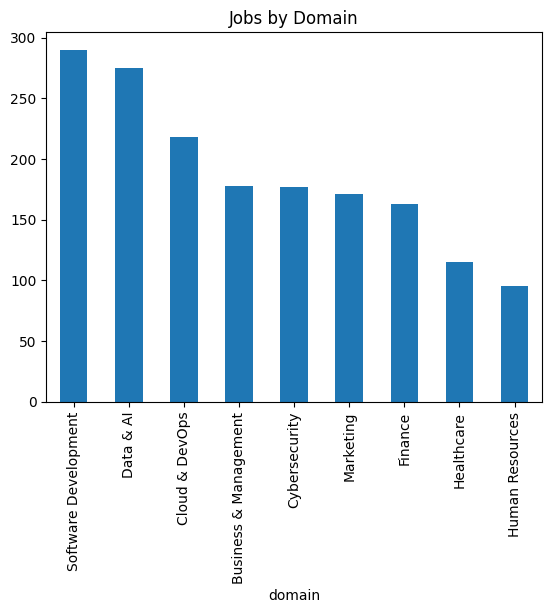

In [38]:

df['domain'].value_counts().head(10).plot(kind='bar')
plt.title("Jobs by Domain")

##### Data & AI and Software Development have the highest number of postings, followed by Cloud & DevOps. Traditional domains like Healthcare and Human Resources have comparatively fewer postings. This reflects the current demand shift toward technology-driven roles in India.


### Jobs by Role — Horizontal Bar Chart

#### A horizontal bar chart showing top 15 most common standardized job roles across all domains

Text(0.5, 1.0, 'Jobs by Role')

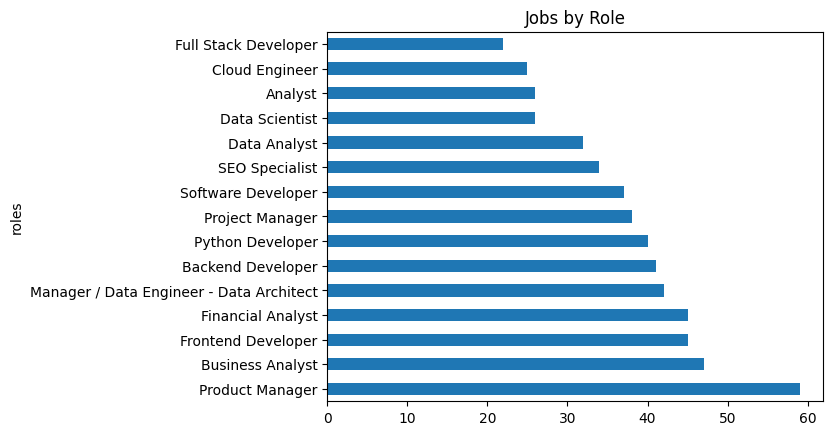

In [39]:
df['roles'].value_counts().head(15).plot(kind='barh')
plt.title("Jobs by Role")

##### Data Scientist, Software Developer and Business Analyst appear as the top 3 most posted roles.Horizontal bars are used here because role names are long — this prevents label overlap and makes the chart readable.

### Work Mode Distribution — Pie Chart

#### A pie chart showing the percentage split of jobs by work mode: Onsite, Hybrid and Remote.


Text(0.5, 1.0, 'Work Mode Distribution')

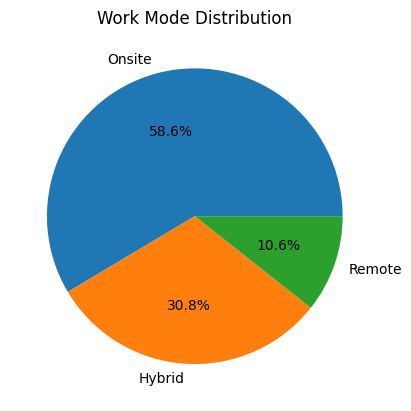

In [40]:
df['work_mode'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Work Mode Distribution")

##### Onsite jobs dominate at 60%, followed by Hybrid at 30% and Remote at just 10%. This shows that despite the post-COVID shift toward remote work, the majority of Indian employers still prefer or require physical presence.


### Employment Type Distribution — Pie Chart


#### A pie chart showing the breakdown of Full-time, Contract, and Internship job postings.

Text(0.5, 1.0, 'Employment Type Distribution')

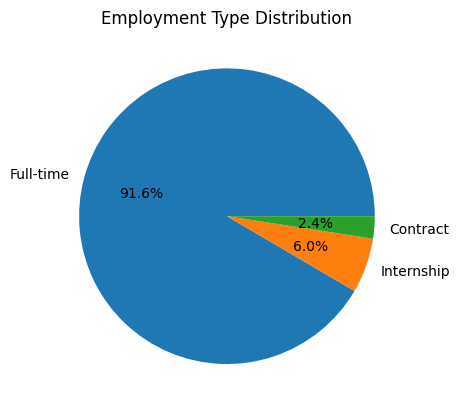

In [41]:
df['employment_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Employment Type Distribution")

##### Full-time positions dominate at 92%. Internships account for 6% and Contract roles for 2%. This indicates that the Indian job market is predominantly full-time employment driven, unlike Western markets where gig and contract work are more common.


### Salary Distribution — Histogram


#### A histogram showing the distribution of average salary values (in Lacs PA) across all jobs that disclosed salary information.

In [42]:
df['Avg_Salary'] = (df['Min_Salary'] + df['Max_Salary']) / 2

Text(0.5, 1.0, 'Salary Distribution')

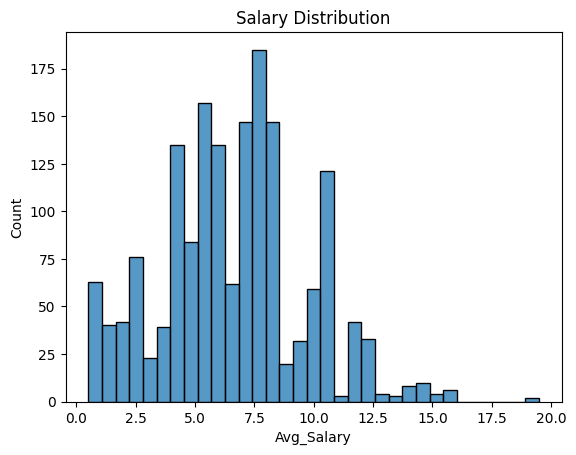

In [43]:
import seaborn as sns
sns.histplot(df['Avg_Salary'])
plt.title("Salary Distribution")

##### The distribution is right-skewed — most disclosed salaries cluster in the 5 to 20 Lacs range, with a long tail of high-paying roles above 30 Lacs. The majority of jobs in the dataset did NOT disclose salary (shown as NaN), which is a known pattern on Naukri.com.

### Top Paying Domains — Horizontal Bar Chart


#### Shows average disclosed salary by domain, sorted from lowest to highest`

Text(0.5, 1.0, 'Top Paying Domains')

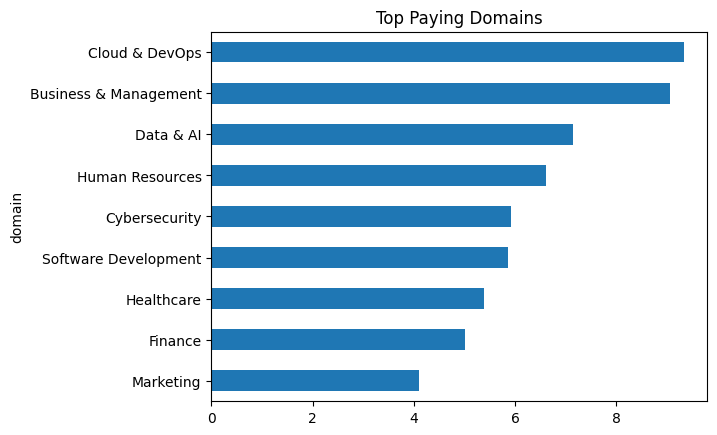

In [44]:
df.groupby('domain')['Avg_Salary'].mean().sort_values().plot(kind='barh')
plt.title("Top Paying Domains")

##### Finance and Data & AI domains show the highest average salaries among those that disclosed compensation. Cloud & DevOps and Cybersecurity also rank high. Marketing and HR roles show lower average salaries among disclosed postings.

### Experience Distribution — Histogram

#### A histogram of average experience (midpoint of Min and Max experience) required across all job postings.


In [45]:
df['Avg_Exp'] = (df['Min_Exp'] + df['Max_Exp']) / 2

Text(0.5, 1.0, 'Experience Distribution')

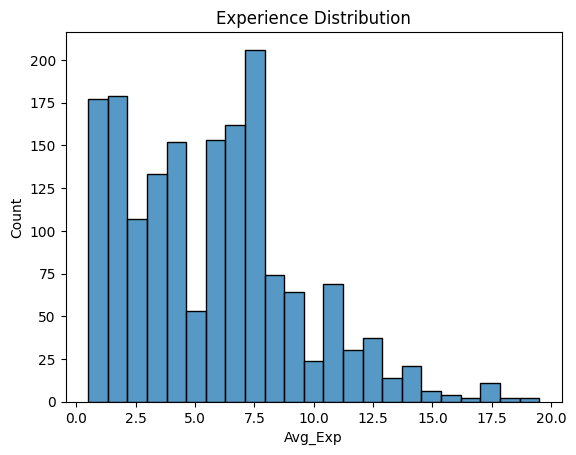

In [46]:
sns.histplot(df['Avg_Exp'])
plt.title("Experience Distribution")

##### The distribution peaks between 3 and 8 years of experience. Very few jobs require 0-1 years (freshers) or 15+ years (senior leadership). The sweet spot of demand is mid-level professionals.

## Bivariate Analysis

### Experience vs Salary — Scatter Plot

#### A scatter plot mapping each job's average experience requirement against its average disclosed salary

Text(0.5, 1.0, 'Experience vs Salary')

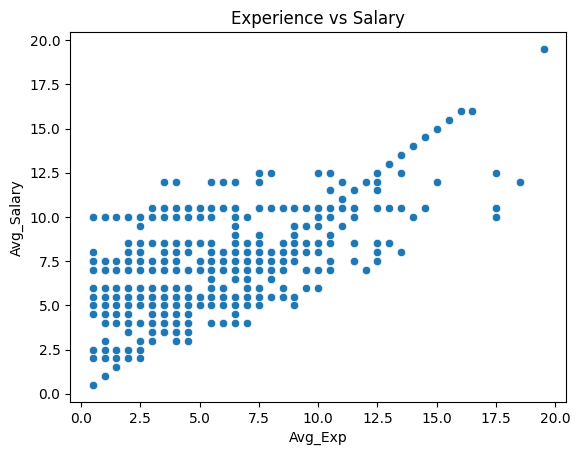

In [47]:
sns.scatterplot(x='Avg_Exp', y='Avg_Salary', data=df)
plt.title("Experience vs Salary")

##### There is a visible positive trend — jobs requiring more experience tend to offer higher salaries. However, the scatter is wide, indicating significant variance. Some low-experience roles in Finance or Data & AI pay very well, while some high-experience roles in traditional domains pay comparatively les

### Domain vs Salary — Box Plot


#### A box plot showing the salary range (median, quartiles, outliers) for each domain.

Text(0.5, 1.0, 'Domain vs Salary')

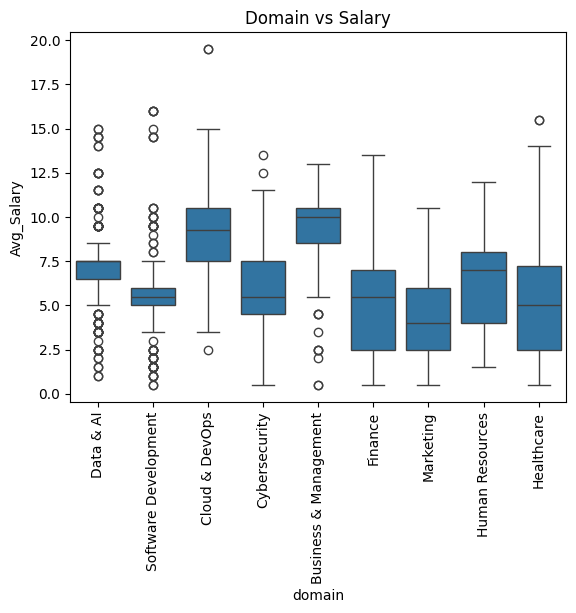

In [48]:
sns.boxplot(x='domain', y='Avg_Salary', data=df)
plt.xticks(rotation=90)
plt.title("Domain vs Salary")

#### Finance shows the highest median salary with a wide interquartile range, indicating both entry-level and senior roles with very different pay. Data & AI has a tighter, consistently high salary range. Marketing and HR have the lowest medians. Multiple outliers exist in all domains — these represent senior or specialized roles.

### Work Mode vs Salary — Box Plot

#### A box plot comparing salary distributions across the three work modes: Onsite, Hybrid, and Remote

Text(0.5, 1.0, 'Work Mode vs Salary')

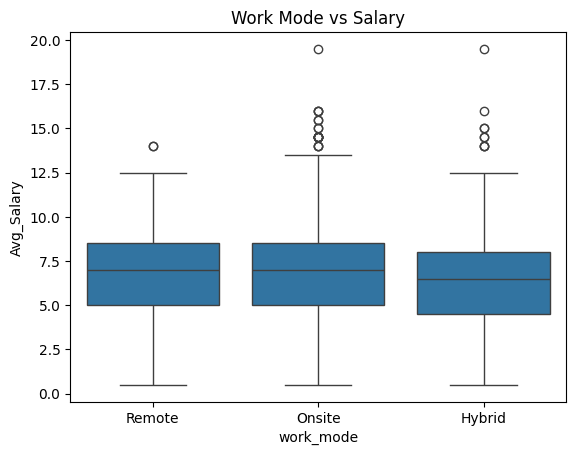

In [49]:
sns.boxplot(x='work_mode', y='Avg_Salary', data=df)
plt.title("Work Mode vs Salary")

##### Remote roles show a slightly higher median salary compared to Onsite and Hybrid. This is likely because remote roles in India are often offered by multinational companies or startups that compete globally for talent. However, the sample of remote jobs is small, so this pattern should be interpreted cautiously.


## Hypothesis 1: Remote Jobs Have Higher Salaries Than Onsite Jobs

##### H₀ (Null Hypothesis)

There is no significant difference in average salary between Remote and Onsite jobs.

##### H₁ (Alternative Hypothesis)

There is a significant difference in average salary between Remote and Onsite jobs.

In [50]:
from scipy.stats import ttest_ind

df['Avg_Salary'] = (df['Min_Salary'] + df['Max_Salary']) / 2

remote_salary = df[df['work_mode']=='Remote']['Avg_Salary']
onsite_salary = df[df['work_mode']=='Onsite']['Avg_Salary']

t_stat, p_value = ttest_ind(remote_salary, onsite_salary)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

T-statistic: -0.25643739516980363
P-value: 0.797658508480259
Fail to Reject H0


## Hypothesis 2: Salary Depends on Domain

##### H₀

Average salary is the same across all domains.

##### H₁

At least one domain has a different average salary.

In [51]:
from scipy.stats import f_oneway

groups = [group['Avg_Salary'].values
          for _, group in df.groupby('domain')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

F-statistic: 88.96847722356769
P-value: 4.4096788058506624e-123
Reject H0


## Hypothesis 3: Employment Type and Work Mode are Related

##### H₀

Employment Type and Work Mode are independent.

##### H₁

Employment Type and Work Mode are associated.

In [52]:
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df['employment_type'],
                         df['work_mode'])

chi2, p_value, dof, expected = chi2_contingency(cont_table)

print("Chi-Square:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Chi-Square: 3.0113076404392025
P-value: 0.5559348801277659
Fail to Reject H0


## Hypothesis 4: Experience Affects Salary

##### H₀

There is no relationship between experience and salary.

##### H₁

There is a relationship between experience and salary.

In [53]:
from scipy.stats import pearsonr

df['Avg_Exp'] = (df['Min_Exp'] + df['Max_Exp']) / 2

corr, p_value = pearsonr(df['Avg_Exp'],
                         df['Avg_Salary'])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Correlation: 0.7544778225314822
P-value: 1.485290885900704e-309
Reject H0


# 4. Key Findings — Narrative Summary

## Location

Bengaluru, Hyderabad and Mumbai are the top 3 job hubs across all 9 domains. Hyderabad
dominates in Data & AI and Healthcare. Bengaluru leads in Software Development and Cloud
& DevOps

## Domain

Data & AI and Software Development account for the highest job postings. Together they
represent nearly 40% of all scraped listings — reflecting India's ongoing technology boom.

## Salary

Over 75% of job postings did NOT disclose salary. Among those that did, the most common
range is 8–15 Lacs PA. Finance and Data & AI lead in disclosed average salary.

## Skills

Python, Machine Learning, SQL, Communication, and Data Analysis are the top 5 in-demand
skills across all domains. AWS and Excel are also consistently demanded.

## Experience

The sweet spot of demand is 3–8 years of experience. Very few postings target freshers (0-1
yr) or senior leadership (15+ yrs).


## Companies

TCS, Accenture, Infosys, Wipro, and HCLTech are the top hiring companies across multiple
domains — confirming the dominance of IT services giants in Indian hiring.

## Work Mode

Onsite roles dominate (60%). Remote roles are a minority (10%) but tend to offer slightly
higher compensation on average.



In [54]:
import pandas as pd

In [55]:
df = pd.DataFrame({'Name':['Rathan','Karthik','Rohit','Nihanth'],
             'Age':[26,27,28,29],
              'Experience':[2,3,4,5],
              'Salary':[67000,11000,12000,13000]
             })

In [56]:
df

,Name,Age,Experience,Salary
0,Rathan,26,2,67000
1,Karthik,27,3,11000
2,Rohit,28,4,12000
3,Nihanth,29,5,13000


In [57]:
avg_salary = df['Salary'].mean()

In [58]:
avg_salary

np.float64(25750.0)

In [66]:
import seaborn as sns

<Axes: xlabel='Experience', ylabel='Salary'>

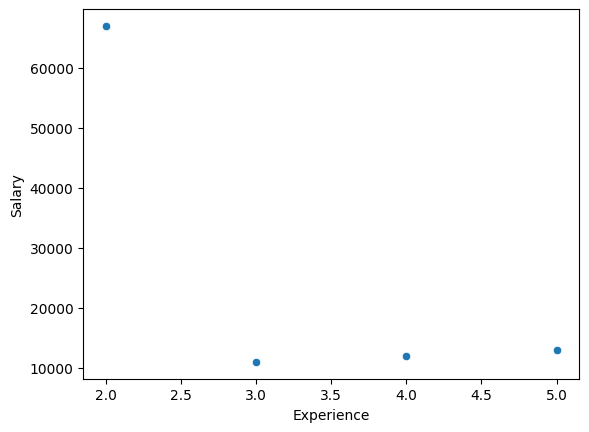

In [69]:
sns.scatterplot(df,x='Experience',y='Salary')

In [74]:
df['Salary'].corr(df['Experience'])

np.float64(-0.7554856450966848)

In [77]:
a = 'madam'

palindrome = a[::-1]


if (a == palindrome):
    print("it is palindrome")
else:
    print("not a palindrome")

it is palindrome
